In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

train_dataset_f = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_f = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

X_train = train_dataset_f.data[:10000].numpy().reshape(-1, 784) / 255.0
y_train = train_dataset_f.targets[:10000].numpy()

X_test = test_dataset_f.data[:2000].numpy().reshape(-1, 784) / 255.0
y_test = test_dataset_f.targets[:2000].numpy()

print(f"\nTraining Shape: {X_train.shape}")


Training Shape: (10000, 784)


In [8]:
from sklearn.random_projection import GaussianRandomProjection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

print("Starting Pipeline 1: Raw Pixels -> Random Projection -> Classifier")

target_dimension = 16
print(f"\nCompressing from 784 down to {target_dimension} dimensions")

rp = GaussianRandomProjection(n_components=target_dimension, random_state=42)

start_time = time.time()
X_train_compressed = rp.fit_transform(X_train)
X_test_compressed = rp.transform(X_test)
print(f"Compression finished in {time.time() - start_time:.2f} seconds")

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_compressed, y_train)

predictions = classifier.predict(X_test_compressed)
accuracy = accuracy_score(y_test, predictions)

print(f"\nAccuracy with only 16 numbers: {accuracy * 100:.2f}%")

Starting Pipeline 1: Raw Pixels -> Random Projection -> Classifier

Compressing from 784 down to 16 dimensions
Compression finished in 0.04 seconds

Accuracy with only 16 numbers: 67.75%


Running the full evaluation for Pipeline 1 (Raw Pixels)
 Testing Dimension: 2 
 Testing Dimension: 4 
 Testing Dimension: 8 
 Testing Dimension: 16 
 Testing Dimension: 32 
 Testing Dimension: 64 
 Testing Dimension: 128 


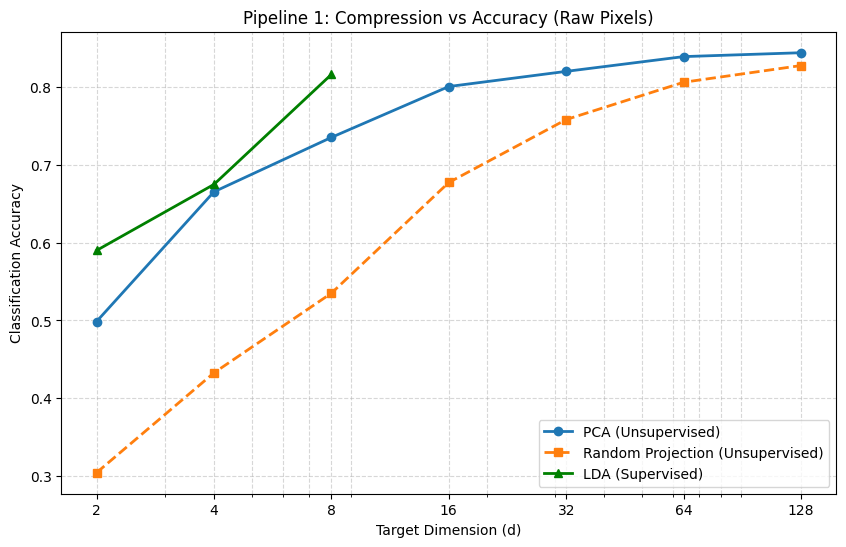

In [9]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

print("Running the full evaluation for Pipeline 1 (Raw Pixels)")

target_dims = [2, 4, 8, 16, 32, 64, 128]

results_pca = []
results_rp = []
results_lda = []

for d in target_dims:
    print(f" Testing Dimension: {d} ")

    pca = PCA(n_components=d)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    clf_pca = LogisticRegression(max_iter=1000)
    clf_pca.fit(X_train_pca, y_train)
    results_pca.append(accuracy_score(y_test, clf_pca.predict(X_test_pca)))

    rp = GaussianRandomProjection(n_components=d, random_state=42)
    X_train_rp = rp.fit_transform(X_train)
    X_test_rp = rp.transform(X_test)

    clf_rp = LogisticRegression(max_iter=1000)
    clf_rp.fit(X_train_rp, y_train)
    results_rp.append(accuracy_score(y_test, clf_rp.predict(X_test_rp)))

    if d <= 9:
        lda = LinearDiscriminantAnalysis(n_components=d)
        X_train_lda = lda.fit_transform(X_train, y_train)
        X_test_lda = lda.transform(X_test)

        clf_lda = LogisticRegression(max_iter=1000)
        clf_lda.fit(X_train_lda, y_train)
        results_lda.append(accuracy_score(y_test, clf_lda.predict(X_test_lda)))
    else:
        results_lda.append(None)


plt.figure(figsize=(10, 6))
plt.plot(target_dims, results_pca, marker='o', linewidth=2, label='PCA (Unsupervised)')
plt.plot(target_dims, results_rp, marker='s', linewidth=2, linestyle='--', label='Random Projection (Unsupervised)')
lda_dims = [d for d, acc in zip(target_dims, results_lda) if acc is not None]
lda_accs = [acc for acc in results_lda if acc is not None]
plt.plot(lda_dims, lda_accs, marker='^', linewidth=2, color='green', label='LDA (Supervised)')
plt.xscale('log')
plt.xticks(target_dims, labels=target_dims)
plt.xlabel('Target Dimension (d)')
plt.ylabel('Classification Accuracy')
plt.title('Pipeline 1: Compression vs Accuracy (Raw Pixels)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

print("Starting Pipeline 2: LeNet-5 CNN Feature Extraction")

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def extract_features(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        return F.relu(self.fc2(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_lenet = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor()
])

train_data_lenet_f = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_lenet)
test_data_lenet_f = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_lenet)

train_loader = torch.utils.data.DataLoader(train_data_lenet_f, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data_lenet_f, batch_size=1000, shuffle=False)

model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
print(f"Training LeNet-5 for {epochs} epochs")

for epoch in range(epochs):
    model.train()
    start_time = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} completed in {time.time() - start_time:.1f} seconds")

model.eval()
features_train, labels_train = [], []
features_test, labels_test = [], []

with torch.no_grad():
    subset_train_loader = DataLoader(torch.utils.data.Subset(train_data_lenet_f, range(10000)), batch_size=1000)
    subset_test_loader = DataLoader(torch.utils.data.Subset(test_data_lenet_f, range(2000)), batch_size=1000)

    for images, labels in subset_train_loader:
        feats = model.extract_features(images.to(device))
        features_train.append(feats.cpu())
        labels_train.append(labels)

    for images, labels in subset_test_loader:
        feats = model.extract_features(images.to(device))
        features_test.append(feats.cpu())
        labels_test.append(labels)

X_train_cnn = torch.cat(features_train).numpy()
y_train_cnn = torch.cat(labels_train).numpy()
X_test_cnn = torch.cat(features_test).numpy()
y_test_cnn = torch.cat(labels_test).numpy()


print(f"\n Extracted CNN Training Features Shape: {X_train_cnn.shape} (10,000 images, 84 features each)")

Starting Pipeline 2: LeNet-5 CNN Feature Extraction
Using device: cuda
Training LeNet-5 for 15 epochs
Epoch 1 completed in 12.7 seconds
Epoch 2 completed in 12.7 seconds
Epoch 3 completed in 12.4 seconds
Epoch 4 completed in 12.4 seconds
Epoch 5 completed in 13.2 seconds
Epoch 6 completed in 12.6 seconds
Epoch 7 completed in 12.7 seconds
Epoch 8 completed in 12.6 seconds
Epoch 9 completed in 12.5 seconds
Epoch 10 completed in 12.5 seconds
Epoch 11 completed in 12.9 seconds
Epoch 12 completed in 12.8 seconds
Epoch 13 completed in 12.0 seconds
Epoch 14 completed in 12.5 seconds
Epoch 15 completed in 12.6 seconds

 Extracted CNN Training Features Shape: (10000, 84) (10,000 images, 84 features each)


Running Pipeline 2 (CNN Features)
 Testing Dimension: 2 
 Testing Dimension: 4 
 Testing Dimension: 8 
 Testing Dimension: 16 
 Testing Dimension: 32 
 Testing Dimension: 64 


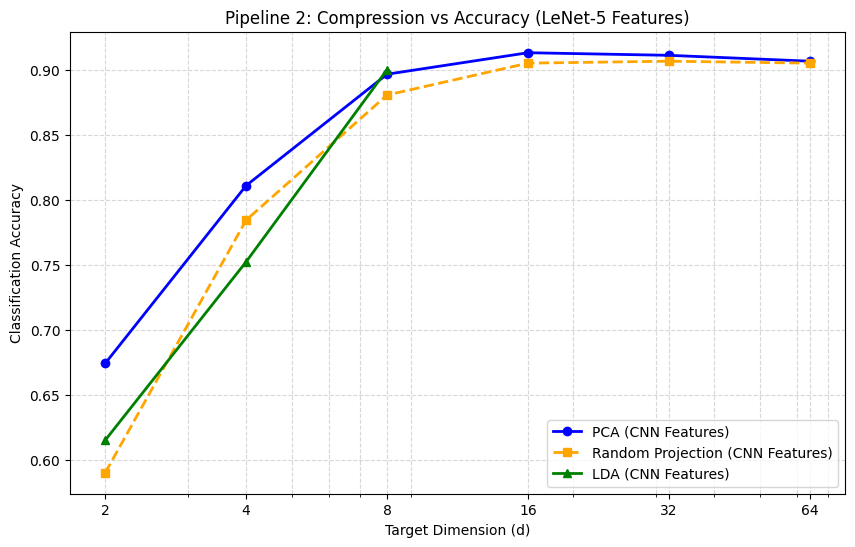

In [11]:
print("Running Pipeline 2 (CNN Features)")

target_dims_cnn = [2, 4, 8, 16, 32, 64]

results_pca_cnn = []
results_rp_cnn = []
results_lda_cnn = []

for d in target_dims_cnn:
    print(f" Testing Dimension: {d} ")
    pca = PCA(n_components=d)
    X_train_pca = pca.fit_transform(X_train_cnn)
    X_test_pca = pca.transform(X_test_cnn)

    clf_pca = LogisticRegression(max_iter=1000)
    clf_pca.fit(X_train_pca, y_train_cnn)
    results_pca_cnn.append(accuracy_score(y_test_cnn, clf_pca.predict(X_test_pca)))

    rp = GaussianRandomProjection(n_components=d, random_state=42)
    X_train_rp = rp.fit_transform(X_train_cnn)
    X_test_rp = rp.transform(X_test_cnn)

    clf_rp = LogisticRegression(max_iter=1000)
    clf_rp.fit(X_train_rp, y_train_cnn)
    results_rp_cnn.append(accuracy_score(y_test_cnn, clf_rp.predict(X_test_rp)))

    if d <= 9:
        lda = LinearDiscriminantAnalysis(n_components=d)
        X_train_lda = lda.fit_transform(X_train_cnn, y_train_cnn)
        X_test_lda = lda.transform(X_test_cnn)

        clf_lda = LogisticRegression(max_iter=1000)
        clf_lda.fit(X_train_lda, y_train_cnn)
        results_lda_cnn.append(accuracy_score(y_test_cnn, clf_lda.predict(X_test_lda)))
    else:
        results_lda_cnn.append(None)

plt.figure(figsize=(10, 6))

plt.plot(target_dims_cnn, results_pca_cnn, marker='o', linewidth=2, color='blue', label='PCA (CNN Features)')
plt.plot(target_dims_cnn, results_rp_cnn, marker='s', linewidth=2, color='orange', linestyle='--', label='Random Projection (CNN Features)')

lda_dims_cnn = [d for d, acc in zip(target_dims_cnn, results_lda_cnn) if acc is not None]
lda_accs_cnn = [acc for acc in results_lda_cnn if acc is not None]
plt.plot(lda_dims_cnn, lda_accs_cnn, marker='^', linewidth=2, color='green', label='LDA (CNN Features)')

plt.xscale('log')
plt.xticks(target_dims_cnn, labels=target_dims_cnn)
plt.xlabel('Target Dimension (d)')
plt.ylabel('Classification Accuracy')
plt.title('Pipeline 2: Compression vs Accuracy (LeNet-5 Features)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("Starting the Deep Baseline: Standard Autoencoder on CNN Features")

train_dataset_ae = TensorDataset(torch.tensor(X_train_cnn).float(), torch.tensor(y_train_cnn))
train_loader_ae = DataLoader(train_dataset_ae, batch_size=64, shuffle=True)

results_ae_cnn = []
target_dims_cnn = [2, 4, 8, 16, 32, 64]

class StandardAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(StandardAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

for d in target_dims_cnn:
    print(f"\n Training Autoencoder for Dimension: {d} ")

    ae_model = StandardAutoencoder(input_dim=84, latent_dim=d).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(ae_model.parameters(), lr=0.005)
    ae_model.train()
    for epoch in range(50):
        for data, _ in train_loader_ae:
            data = data.to(device)
            optimizer.zero_grad()
            reconstructed, _ = ae_model(data)
            loss = criterion(reconstructed, data)
            loss.backward()
            optimizer.step()

    ae_model.eval()
    with torch.no_grad():
        _, X_train_encoded = ae_model(torch.tensor(X_train_cnn).float().to(device))
        _, X_test_encoded = ae_model(torch.tensor(X_test_cnn).float().to(device))

    X_train_encoded = X_train_encoded.cpu().numpy()
    X_test_encoded = X_test_encoded.cpu().numpy()

    clf_ae = LogisticRegression(max_iter=1000)
    clf_ae.fit(X_train_encoded, y_train_cnn)
    acc = accuracy_score(y_test_cnn, clf_ae.predict(X_test_encoded))
    results_ae_cnn.append(acc)
    print(f"Autoencoder Accuracy (d={d}): {acc * 100:.2f}%")


Starting the Deep Baseline: Standard Autoencoder on CNN Features

 Training Autoencoder for Dimension: 2 
Autoencoder Accuracy (d=2): 86.15%

 Training Autoencoder for Dimension: 4 
Autoencoder Accuracy (d=4): 90.25%

 Training Autoencoder for Dimension: 8 
Autoencoder Accuracy (d=8): 90.55%

 Training Autoencoder for Dimension: 16 
Autoencoder Accuracy (d=16): 90.60%

 Training Autoencoder for Dimension: 32 
Autoencoder Accuracy (d=32): 91.40%

 Training Autoencoder for Dimension: 64 
Autoencoder Accuracy (d=64): 90.70%


 Supervised C-GMVAE Adaptation

 Training C-GMVAE for Dimension: 2 
C-GMVAE Accuracy (d=2): 86.25%

 Training C-GMVAE for Dimension: 4 
C-GMVAE Accuracy (d=4): 90.50%

 Training C-GMVAE for Dimension: 8 
C-GMVAE Accuracy (d=8): 91.55%

 Training C-GMVAE for Dimension: 16 
C-GMVAE Accuracy (d=16): 91.55%

 Training C-GMVAE for Dimension: 32 
C-GMVAE Accuracy (d=32): 91.30%

 Training C-GMVAE for Dimension: 64 
C-GMVAE Accuracy (d=64): 91.50%


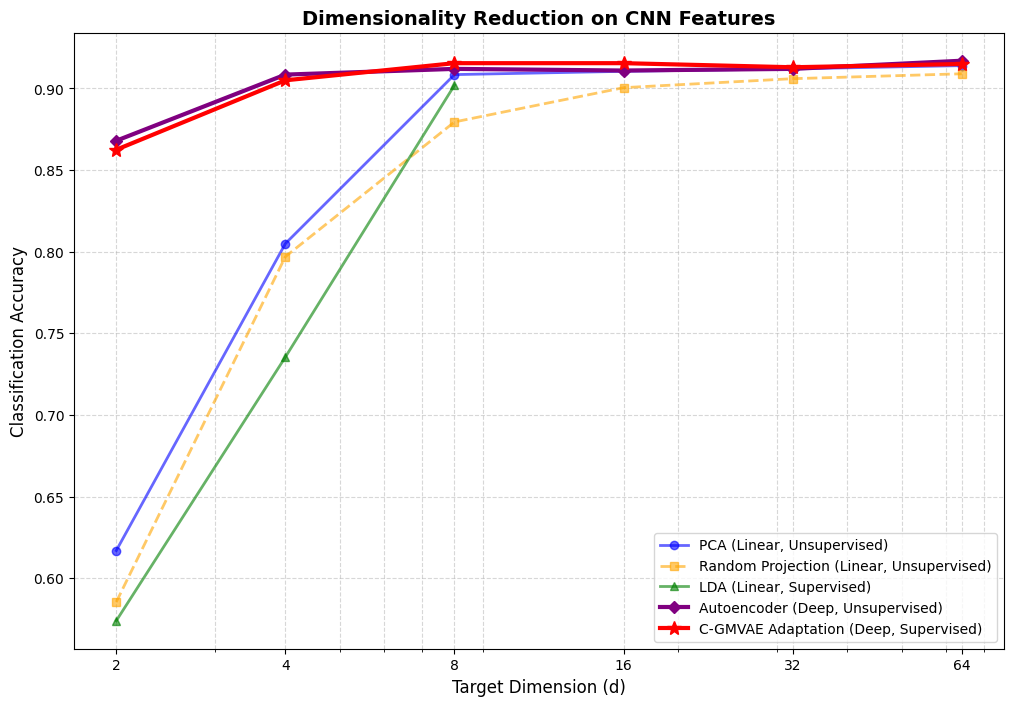

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

print(" Supervised C-GMVAE Adaptation")

train_dataset_cgmvae = TensorDataset(torch.tensor(X_train_cnn).float(), torch.tensor(y_train_cnn).long())
train_loader_cgmvae = DataLoader(train_dataset_cgmvae, batch_size=64, shuffle=True)

results_cgmvae_cnn = []
target_dims_cnn = [2, 4, 8, 16, 32, 64]

class SupervisedGMVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_classes=10):
        super(SupervisedGMVAE, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU())
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.class_centroids = nn.Embedding(num_classes, latent_dim)

        self.decoder = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(), nn.Linear(64, input_dim))

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        prior_mu = self.class_centroids(labels)

        return reconstructed, mu, logvar, prior_mu

for d in target_dims_cnn:
    print(f"\n Training C-GMVAE for Dimension: {d} ")

    model_cgmvae = SupervisedGMVAE(input_dim=84, latent_dim=d).to(device)
    optimizer = optim.Adam(model_cgmvae.parameters(), lr=0.005)

    model_cgmvae.train()
    for epoch in range(50):
        for data, labels in train_loader_cgmvae:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()

            reconstructed, mu, logvar, prior_mu = model_cgmvae(data, labels)

            recon_loss = F.mse_loss(reconstructed, data, reduction='sum')

            kl_loss = -0.5 * torch.sum(1 + logvar - (mu - prior_mu).pow(2) - logvar.exp())

            total_loss = recon_loss + kl_loss
            total_loss.backward()
            optimizer.step()

    model_cgmvae.eval()
    with torch.no_grad():
        X_train_cgmvae, _ = model_cgmvae.encode(torch.tensor(X_train_cnn).float().to(device))
        X_test_cgmvae, _ = model_cgmvae.encode(torch.tensor(X_test_cnn).float().to(device))

    X_train_cgmvae = X_train_cgmvae.cpu().numpy()
    X_test_cgmvae = X_test_cgmvae.cpu().numpy()

    clf_cgmvae = LogisticRegression(max_iter=1000)
    clf_cgmvae.fit(X_train_cgmvae, y_train_cnn)
    acc = accuracy_score(y_test_cnn, clf_cgmvae.predict(X_test_cgmvae))
    results_cgmvae_cnn.append(acc)
    print(f"C-GMVAE Accuracy (d={d}): {acc * 100:.2f}%")

plt.figure(figsize=(12, 8))

plt.plot(target_dims_cnn, results_pca_cnn, marker='o', linewidth=2, color='blue', alpha=0.6, label='PCA (Linear, Unsupervised)')
plt.plot(target_dims_cnn, results_rp_cnn, marker='s', linewidth=2, color='orange', linestyle='--', alpha=0.6, label='Random Projection (Linear, Unsupervised)')

lda_dims_cnn = [d for d, acc in zip(target_dims_cnn, results_lda_cnn) if acc is not None]
lda_accs_cnn = [acc for acc in results_lda_cnn if acc is not None]
plt.plot(lda_dims_cnn, lda_accs_cnn, marker='^', linewidth=2, color='green', alpha=0.6, label='LDA (Linear, Supervised)')

plt.plot(target_dims_cnn, results_ae_cnn, marker='D', linewidth=3, color='purple', label='Autoencoder (Deep, Unsupervised)')
plt.plot(target_dims_cnn, results_cgmvae_cnn, marker='*', markersize=10, linewidth=3, color='red', label='C-GMVAE Adaptation (Deep, Supervised)')

plt.xscale('log')
plt.xticks(target_dims_cnn, labels=target_dims_cnn)
plt.xlabel('Target Dimension (d)', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.title('Dimensionality Reduction on CNN Features', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()